# Injection-recovery test ($\Delta\log_{10}\text{BF}$ Vs $e_0$) for GW190425-like event

In [7]:
import numpy as np
import bilby
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import fsolve

size_axis_label = 13
size_tick_label = 11
size_legend_label = 12

In [8]:
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_Ecck_e0_0p01_data0_1126259642-413_analysis_H1L1_result.hdf5")
snr_L1 = result.meta_data['likelihood']['interferometers']['L1']['optimal_SNR']
snr_H1 = result.meta_data['likelihood']['interferometers']['H1']['optimal_SNR']
snr_net = np.sqrt(snr_L1**2 + snr_H1**2)
print(f"Optimal SNR in L1: {snr_L1:.2f}")

05:53 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


Optimal SNR in L1: 12.93


In [9]:
# you can see other meta data including the injection parameters, priors, etc. using
# result.meta_data

## Fetching data 


In [10]:
# TaylorF2Ecck 
# e0=0.01
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_Ecck_e0_0p01_data0_1126259642-413_analysis_H1L1_result.hdf5")
ecck_0p01 = result.log_10_bayes_factor
# e0=0.03
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_Ecck_e0_0p03_data0_1126259642-413_analysis_H1L1_result.hdf5")
ecck_0p03 = result.log_10_bayes_factor
# e0=0.07
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_Ecck_e0_0p07_data0_1126259642-413_analysis_H1L1_result.hdf5")
ecck_0p07 = result.log_10_bayes_factor
# e0=0.10
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_Ecck_e0_0p1_data0_1126259642-413_analysis_H1L1_result.hdf5")
ecck_0p10 = result.log_10_bayes_factor

# TaylorF2
# e0=0.01
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_TF2_e0_0p01_data0_1126259642-413_analysis_H1L1_result.hdf5")
tf2_0p01 = result.log_10_bayes_factor
# e0=0.03
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_TF2_e0_0p03_data0_1126259642-413_analysis_H1L1_result.hdf5")
tf2_0p03 = result.log_10_bayes_factor
# e0=0.07
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_TF2_e0_0p07_data0_1126259642-413_analysis_H1L1_result.hdf5")
tf2_0p07 = result.log_10_bayes_factor
# e0=0.10
result = bilby.result.read_in_result("../injection_recover_PE_results/GW190425_TF2_e0_0p1_data0_1126259642-413_analysis_H1L1_result.hdf5")
tf2_0p1 = result.log_10_bayes_factor

05:53 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
05:53 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
05:53 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
05:53 bilby INFO    : Global meta data was removed from the result object for compatibility

In [11]:
# TaylorF2Ecck vs TaylorF2
bf_tf2 = np.array([ecck_0p01-tf2_0p01, ecck_0p03-tf2_0p03, ecck_0p07-tf2_0p07, ecck_0p10-tf2_0p1])
e0_tf2 = np.array([0.01, 0.03, 0.07, 0.1])
bf_tf2, e0_tf2

(array([-1.41015944,  9.62837969, 41.19590248, 57.85762289]),
 array([0.01, 0.03, 0.07, 0.1 ]))

In [12]:
# curve fitting
# fit spline
# TaylorF2Ecck vs TaylorF2
cs_tf2 = CubicSpline(e0_tf2, bf_tf2, extrapolate=True)
e0_spline_tf2_jf = fsolve(lambda x: cs_tf2(x) - 8, 0.05)[0]
print(f"e0 spline at bf = 8 (Jeffereys' criteria): {e0_spline_tf2_jf}")

e0 spline at bf = 8 (Jeffereys' criteria): 0.0276126267584553


In [13]:
# curve fitting
# fit spline
# TaylorF2Ecck vs TaylorF2
cs_tf2 = CubicSpline(e0_tf2, bf_tf2, extrapolate=True)
e0_spline_tf2_bf2 = fsolve(lambda x: cs_tf2(x) - 2, 0.05)[0]
print(f"e0 spline at bf = 2: {e0_spline_tf2_bf2}")

e0 spline at bf = 2: 0.017577695860445382


In [14]:
# curve fitting
# fit spline
# TaylorF2Ecck vs TaylorF2
cs_tf2 = CubicSpline(e0_tf2, bf_tf2, extrapolate=True)
e0_spline_tf2_bf1 = fsolve(lambda x: cs_tf2(x) - 1, 0.05)[0]
print(f"e0 spline at bf = 1: {e0_spline_tf2_bf1}")

e0 spline at bf = 1: 0.015587188873573748


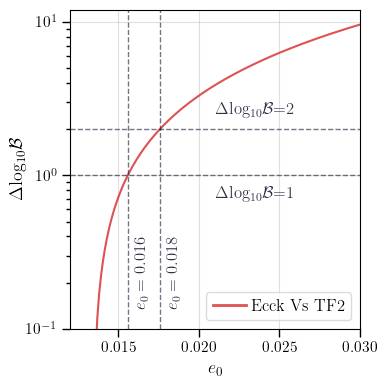

In [ ]:
e0_array2 = np.geomspace(0.001, 0.06, 500)

# Setup the figure
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": size_tick_label,
    "axes.labelsize": size_axis_label,
    "axes.titlesize": size_axis_label,
    "xtick.labelsize": size_tick_label,
    "ytick.labelsize": size_tick_label,
    "legend.fontsize": size_legend_label,
    "figure.titlesize": size_axis_label
})
plt.figure(figsize=(4, 4))
plt.plot(e0_array2, cs_tf2(e0_array2), label='Ecck Vs TF2', color='C3', alpha=0.8)

# Labeling the first plot
plt.xlabel(r"$e_0$", fontdict={'fontsize': size_axis_label})
plt.ylabel(r'$\Delta$log$_{10}{\cal B}$', labelpad=0, fontdict={'fontsize': size_axis_label})

plt.tick_params(axis='both', which='both', labelsize=size_tick_label)
legend = plt.legend(handlelength=2, loc='lower right', bbox_to_anchor=(1.0, 0.0), frameon=True, fontsize=size_legend_label, edgecolor='lightgray')
# # rounded box for legend
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
# Modify line width for legend entries
for handle in legend.get_lines():
    handle.set_linewidth(2)
    handle.set_alpha(0.8)

# horizontal lines
plt.axhline(y=2.0, color='#1B1833', linestyle='--', linewidth=1, alpha=0.6)
plt.text(0.021, 2.0+0.5, r'$\Delta$log$_{10} {\cal B}$=2', color='#1B1833', fontsize=size_legend_label, alpha=0.9)
plt.axhline(y=1.0, color='#1B1833', linestyle='--', linewidth=1, alpha=0.6)
plt.text(0.021, 1.0-0.30, r'$\Delta$log$_{10} {\cal B}$=1', color='#1B1833', fontsize=size_legend_label, alpha=0.9)

# vertical lines
plt.axvline(x=e0_spline_tf2_bf2, color='#1B1833', linestyle='--', linewidth=1, alpha=0.6)
plt.text(e0_spline_tf2_bf2+0.0004, 0.14, rf'$e_0={e0_spline_tf2_bf2:.3f}$', color='#1B1833', fontsize=size_legend_label, alpha=0.9, rotation=90)
plt.axvline(x=e0_spline_tf2_bf1, color='#1B1833', linestyle='--', linewidth=1, alpha=0.6)
plt.text(e0_spline_tf2_bf1+0.0004, 0.14, rf'$e_0={e0_spline_tf2_bf1:.3f}$', color='#1B1833', fontsize=size_legend_label, alpha=0.9, rotation=90)

plt.xlim(0.012, 0.03)
plt.ylim(0.1, 12.0)
plt.yscale('log')

plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('./bf_vs_eccn_tf2_GW190425.pdf')
plt.show()